## Notes you should put in your report

### Is this still “from scratch”?
Yes, because:
- all model weights are initialized randomly
- training is done on your dataset
- no pretrained TTS checkpoints are loaded
- only standard PyTorch / torchaudio building blocks are used

### Why not merge datasets immediately?
For a first meaningful result, **single-speaker LJSpeech** is the safest option.  
Mixing datasets like LJSpeech and VCTK turns the problem into a **multi-speaker** task and usually needs:
- speaker IDs / speaker embeddings
- stronger normalization
- more training time
- more careful evaluation

### What to try first if results are still weak
1. Train acoustic model longer.
2. Lower batch size if Kaggle memory is tight.
3. Increase `acoustic_epochs`.
4. Keep `teacher_forcing_ratio` high in early training.
5. Train the vocoder longer than the acoustic model.
6. Do not judge quality too early.

### Practical expectations
- The **acoustic model** may start giving visible alignments before audio sounds good.
- The **vocoder** often needs many epochs before audio becomes clearly hearable.
- If alignment is broken, fix the acoustic model first before blaming the vocoder.

In [1]:
# =========================
# Cell 1: IMPORTS
# =========================
import os
import math
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
from tqdm.auto import tqdm

In [2]:
# =========================
# Cell 2: CONFIG
# =========================
class CFG:
    seed = 42

    # data
    data_root = Path("/kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1")
    sample_rate = 22050

    # audio / mel
    n_fft = 1024
    win_length = 1024
    hop_length = 256
    n_mels = 80
    f_min = 0
    f_max = 8000

    # text
    pad_id = 0

    # training
    batch_size = 16
    num_workers = 0   # keep 0 first for stability on Kaggle
    lr = 2e-4
    epochs = 20
    weight_decay = 1e-6
    grad_clip = 1.0

    # model
    d_model = 256
    n_heads = 4
    n_encoder_layers = 4
    encoder_ffn_dim = 1024
    encoder_dropout = 0.1

    decoder_hidden = 256
    prenet_dim = 128
    postnet_channels = 512

    # limits
    max_text_len = 180
    max_mel_len = 900

    # outputs
    work_dir = Path("/kaggle/working/tts_transformer_taco")
    ckpt_dir = work_dir / "checkpoints"
    sample_dir = work_dir / "samples"
    plot_dir = work_dir / "plots"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

CFG.work_dir.mkdir(parents=True, exist_ok=True)
CFG.ckpt_dir.mkdir(parents=True, exist_ok=True)
CFG.sample_dir.mkdir(parents=True, exist_ok=True)
CFG.plot_dir.mkdir(parents=True, exist_ok=True)

DEVICE: cuda


In [3]:
# =========================
# Cell 3: SEED
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

In [4]:
# =========================
# Cell 4: CHECK DATA ROOT
# =========================
print("DATA ROOT:", CFG.data_root)
print("metadata exists:", (CFG.data_root / "metadata.csv").exists())
print("wavs exists:", (CFG.data_root / "wavs").exists())

assert (CFG.data_root / "metadata.csv").exists(), "metadata.csv not found"
assert (CFG.data_root / "wavs").exists(), "wavs folder not found"

print("LJSpeech root found successfully.")

DATA ROOT: /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1
metadata exists: True
wavs exists: True
LJSpeech root found successfully.


In [5]:
# =========================
# Cell 5: LOAD METADATA
# =========================
meta_path = CFG.data_root / "metadata.csv"
df = pd.read_csv(meta_path, sep="|", header=None, quoting=3)
df.columns = ["utt_id", "text", "normalized_text"]

print("Rows:", len(df))
display(df.head())

Rows: 13100


,utt_id,text,normalized_text
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [6]:
# =========================
# Cell 6: TEXT VOCAB
# =========================
all_text = " ".join(df["normalized_text"].astype(str).tolist())
chars = sorted(list(set(all_text)))

stoi = {"<pad>": 0, "<unk>": 1}
for ch in chars:
    if ch not in stoi:
        stoi[ch] = len(stoi)

itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)

print("Vocab size:", vocab_size)
print("Sample chars:", chars[:50])

Vocab size: 77
Sample chars: [' ', '!', '"', "'", '(', ')', ',', '-', '.', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']


In [7]:
# =========================
# Cell 7: TEXT FUNCTIONS
# =========================
def text_to_ids(text):
    text = str(text)
    ids = [stoi.get(ch, stoi["<unk>"]) for ch in text]
    return ids

def ids_to_text(ids):
    return "".join([itos.get(i, "") for i in ids if i in itos])

In [8]:
# =========================
# Cell 8: FILTER DATA
# =========================
import wave
import contextlib
import math
from tqdm.auto import tqdm

def estimate_mel_len_from_wav_path(wav_path, hop_length=256):
    """
    Estimate mel length from WAV file without using torchaudio.info.
    Works well for LJSpeech WAV files.
    """
    with contextlib.closing(wave.open(str(wav_path), "rb")) as wf:
        num_frames = wf.getnframes()
    mel_len = math.ceil(num_frames / hop_length)
    return mel_len

filtered_rows = []
dropped = 0

for _, row in tqdm(df.iterrows(), total=len(df)):
    utt_id = row["utt_id"]
    text = str(row["normalized_text"])
    wav_path = CFG.data_root / "wavs" / f"{utt_id}.wav"

    if not wav_path.exists():
        dropped += 1
        continue

    text_len = len(text_to_ids(text))
    mel_len = estimate_mel_len_from_wav_path(wav_path, CFG.hop_length)

    if text_len > CFG.max_text_len:
        dropped += 1
        continue
    if mel_len > CFG.max_mel_len:
        dropped += 1
        continue

    filtered_rows.append(row)

df_filtered = pd.DataFrame(filtered_rows).reset_index(drop=True)

print("Original rows:", len(df))
print("Filtered rows:", len(df_filtered))
print("Dropped rows:", dropped)
display(df_filtered.head())

  0%|          | 0/13100 [00:00<?, ?it/s]

Original rows: 13100
Filtered rows: 13082
Dropped rows: 18


,utt_id,text,normalized_text
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [9]:
# =========================
# Cell 9: TRAIN / VAL SPLIT
# =========================
val_size = 300

df_shuffled = df_filtered.sample(frac=1.0, random_state=CFG.seed).reset_index(drop=True)
df_val = df_shuffled.iloc[:val_size].reset_index(drop=True)
df_train = df_shuffled.iloc[val_size:].reset_index(drop=True)

print("Train:", len(df_train))
print("Val:", len(df_val))

Train: 12782
Val: 300


In [10]:
# =========================
# Cell 10: MEL TRANSFORM (CPU ONLY)
# =========================
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=CFG.sample_rate,
    n_fft=CFG.n_fft,
    win_length=CFG.win_length,
    hop_length=CFG.hop_length,
    f_min=CFG.f_min,
    f_max=CFG.f_max,
    n_mels=CFG.n_mels,
    power=1.0,
)

def wav_to_mel(wav_1d: torch.Tensor) -> torch.Tensor:
    """
    wav_1d: [T] on CPU
    returns: [n_mels, frames] on CPU
    """
    if wav_1d.dim() == 2:
        wav_1d = wav_1d.squeeze(0)

    wav_1d = wav_1d.float().cpu()
    x = wav_1d.unsqueeze(0)  # [1, T]
    mel = mel_transform(x)   # [1, n_mels, frames]
    mel = torch.log(torch.clamp(mel, min=1e-5))
    mel = mel.squeeze(0).cpu()
    return mel

In [11]:
# =========================
# Cell 11: DATASET
# =========================
class LJSpeechDataset(Dataset):
    def __init__(self, df, data_root):
        self.df = df.reset_index(drop=True)
        self.data_root = Path(data_root)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        utt_id = row["utt_id"]
        text = str(row["normalized_text"])

        wav_path = self.data_root / "wavs" / f"{utt_id}.wav"
        wav, sr = torchaudio.load(str(wav_path))  # CPU

        if sr != CFG.sample_rate:
            wav = torchaudio.functional.resample(wav, sr, CFG.sample_rate)

        wav = wav.mean(dim=0)  # mono => [T]
        wav = wav / max(wav.abs().max().item(), 1e-6)

        text_ids = torch.LongTensor(text_to_ids(text))
        mel = wav_to_mel(wav)  # CPU only

        return {
            "utt_id": utt_id,
            "text": text,
            "text_ids": text_ids,
            "mel": mel,
        }

In [12]:
# =========================
# Cell 12: COLLATE (FIXED)
# =========================
def collate_fn(batch):
    text_lens = [len(x["text_ids"]) for x in batch]
    mel_lens = [x["mel"].shape[1] for x in batch]

    max_text_len = max(text_lens)
    max_mel_len = max(mel_lens)
    bsz = len(batch)

    text_ids = torch.zeros(bsz, max_text_len, dtype=torch.long)
    mels = torch.zeros(bsz, CFG.n_mels, max_mel_len, dtype=torch.float32)

    for i, item in enumerate(batch):
        t = item["text_ids"]
        m = item["mel"]

        text_ids[i, :t.shape[0]] = t
        mels[i, :, :m.shape[1]] = m

    return {
        "utt_id": [x["utt_id"] for x in batch],
        "text": [x["text"] for x in batch],
        "text_ids": text_ids,
        "text_lens": torch.LongTensor(text_lens),
        "mels": mels,
        "mel_lens": torch.LongTensor(mel_lens),
    }

In [13]:
# =========================
# Cell 13: DATALOADERS
# =========================
train_dataset = LJSpeechDataset(df_train, CFG.data_root)
val_dataset = LJSpeechDataset(df_val, CFG.data_root)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=True,
    collate_fn=collate_fn,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
    collate_fn=collate_fn,
    drop_last=False,
)

batch = next(iter(train_loader))
for k, v in batch.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

utt_id <class 'list'> 16
text <class 'list'> 16
text_ids torch.Size([16, 173]) torch.int64
text_lens torch.Size([16]) torch.int64
mels torch.Size([16, 80, 841]) torch.float32
mel_lens torch.Size([16]) torch.int64


In [14]:
# =========================
# Cell 14: POSITIONAL ENCODING
# =========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [B, T, D]
        return x + self.pe[:, :x.size(1)]

In [15]:
# =========================
# Cell 15: TRANSFORMER ENCODER
# =========================
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, num_layers, ffn_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=CFG.pad_id)
        self.pos_enc = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            batch_first=True
        )

        # disable nested tensor optimization to avoid the prototype warning
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False
        )

    def forward(self, text_ids, text_lens):
        x = self.embedding(text_ids)  # [B, T, D]
        x = self.pos_enc(x)

        max_len = text_ids.size(1)
        mask = torch.arange(max_len, device=text_ids.device).unsqueeze(0) >= text_lens.unsqueeze(1)

        x = self.encoder(x, src_key_padding_mask=mask)
        return x

In [16]:
# =========================
# Cell 16: PRENET
# =========================
class Prenet(nn.Module):
    def __init__(self, in_dim, hidden_dim, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = dropout

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x

In [17]:
# =========================
# Cell 17: ADDITIVE ATTENTION
# =========================
class AdditiveAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim):
        super().__init__()
        self.query_proj = nn.Linear(dec_dim, attn_dim, bias=False)
        self.key_proj = nn.Linear(enc_dim, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, query, keys, values, text_lens):
        # query: [B, dec_dim]
        # keys/values: [B, T_text, enc_dim]
        q = self.query_proj(query).unsqueeze(1)   # [B,1,A]
        k = self.key_proj(keys)                   # [B,T,A]
        energy = self.v(torch.tanh(q + k)).squeeze(-1)  # [B,T]

        max_len = keys.size(1)
        mask = torch.arange(max_len, device=keys.device).unsqueeze(0) >= text_lens.unsqueeze(1)
        energy = energy.masked_fill(mask, -1e9)

        attn = torch.softmax(energy, dim=-1)      # [B,T]
        context = torch.bmm(attn.unsqueeze(1), values).squeeze(1)  # [B,enc_dim]
        return context, attn

In [18]:
# =========================
# Cell 18: DECODER
# =========================
class MelDecoder(nn.Module):
    def __init__(self, n_mels, enc_dim, prenet_dim, dec_hidden):
        super().__init__()
        self.prenet = Prenet(n_mels, prenet_dim)
        self.attention_rnn = nn.GRUCell(prenet_dim + enc_dim, dec_hidden)
        self.attention = AdditiveAttention(enc_dim, dec_hidden, dec_hidden)
        self.decoder_rnn = nn.GRUCell(dec_hidden + enc_dim, dec_hidden)

        self.mel_proj = nn.Linear(dec_hidden + enc_dim, n_mels)
        self.stop_proj = nn.Linear(dec_hidden + enc_dim, 1)

    def forward(self, encoder_out, text_lens, target_mels=None, teacher_forcing=True, max_steps=900):
        B = encoder_out.size(0)
        enc_dim = encoder_out.size(2)
        device = encoder_out.device

        if target_mels is not None:
            T_mel = target_mels.size(2)
            steps = T_mel
        else:
            steps = max_steps

        go_frame = torch.zeros(B, CFG.n_mels, device=device)

        attn_hidden = torch.zeros(B, CFG.decoder_hidden, device=device)
        dec_hidden = torch.zeros(B, CFG.decoder_hidden, device=device)
        context = torch.zeros(B, enc_dim, device=device)

        prev_mel = go_frame
        mel_outputs = []
        stop_outputs = []
        attn_maps = []

        for t in range(steps):
            prenet_out = self.prenet(prev_mel)
            attn_input = torch.cat([prenet_out, context], dim=-1)

            attn_hidden = self.attention_rnn(attn_input, attn_hidden)
            context, attn = self.attention(attn_hidden, encoder_out, encoder_out, text_lens)

            dec_input = torch.cat([attn_hidden, context], dim=-1)
            dec_hidden = self.decoder_rnn(dec_input, dec_hidden)

            proj_input = torch.cat([dec_hidden, context], dim=-1)
            mel_t = self.mel_proj(proj_input)
            stop_t = self.stop_proj(proj_input)

            mel_outputs.append(mel_t.unsqueeze(1))
            stop_outputs.append(stop_t.unsqueeze(1))
            attn_maps.append(attn.unsqueeze(1))

            if teacher_forcing and target_mels is not None:
                prev_mel = target_mels[:, :, t]
            else:
                prev_mel = mel_t

        mel_outputs = torch.cat(mel_outputs, dim=1)     # [B,T,n_mels]
        stop_outputs = torch.cat(stop_outputs, dim=1)   # [B,T,1]
        attn_maps = torch.cat(attn_maps, dim=1)         # [B,T,text_len]

        mel_outputs = mel_outputs.transpose(1, 2)       # [B,n_mels,T]
        return mel_outputs, stop_outputs.squeeze(-1), attn_maps

In [19]:
# =========================
# Cell 19: POSTNET
# =========================
class Postnet(nn.Module):
    def __init__(self, n_mels, channels):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_mels, channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(channels),
            nn.Tanh(),
            nn.Dropout(0.5),
        )

        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(channels, channels, kernel_size=5, padding=2),
                nn.BatchNorm1d(channels),
                nn.Tanh(),
                nn.Dropout(0.5),
            ) for _ in range(3)
        ])

        self.conv_out = nn.Sequential(
            nn.Conv1d(channels, n_mels, kernel_size=5, padding=2),
            nn.BatchNorm1d(n_mels),
            nn.Dropout(0.5),
        )

    def forward(self, x):
        x = self.conv1(x)
        for layer in self.convs:
            x = layer(x)
        x = self.conv_out(x)
        return x

In [20]:
# =========================
# Cell 20: FULL MODEL
# =========================
class TransformerTacotron(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = TextEncoder(
            vocab_size=vocab_size,
            d_model=CFG.d_model,
            n_heads=CFG.n_heads,
            num_layers=CFG.n_encoder_layers,
            ffn_dim=CFG.encoder_ffn_dim,
            dropout=CFG.encoder_dropout,
        )
        self.decoder = MelDecoder(
            n_mels=CFG.n_mels,
            enc_dim=CFG.d_model,
            prenet_dim=CFG.prenet_dim,
            dec_hidden=CFG.decoder_hidden,
        )
        self.postnet = Postnet(CFG.n_mels, CFG.postnet_channels)

    def forward(self, text_ids, text_lens, target_mels=None, teacher_forcing=True, max_steps=900):
        enc = self.encoder(text_ids, text_lens)
        mel_out, stop_out, attn = self.decoder(
            enc,
            text_lens,
            target_mels=target_mels,
            teacher_forcing=teacher_forcing,
            max_steps=max_steps,
        )
        mel_post = mel_out + self.postnet(mel_out)
        return mel_out, mel_post, stop_out, attn

In [21]:
# =========================
# Cell 21: TARGET HELPERS
# =========================
def make_stop_targets(mel_lens, max_mel_len):
    stop_targets = torch.zeros(len(mel_lens), max_mel_len, dtype=torch.float32)
    for i, l in enumerate(mel_lens):
        stop_targets[i, l - 1:] = 1.0
    return stop_targets

def make_mel_mask(mel_lens, max_mel_len, device):
    mask = torch.arange(max_mel_len, device=device).unsqueeze(0) < mel_lens.unsqueeze(1)
    return mask

In [22]:
# =========================
# Cell 22: LOSS
# =========================
def tts_loss_fn(mel_out, mel_post, mel_target, stop_out, stop_target, mel_lens):
    # mel_out, mel_post, mel_target: [B,n_mels,T]
    # stop_out, stop_target: [B,T]

    B, n_mels, T = mel_target.shape
    mask = make_mel_mask(mel_lens, T, mel_target.device).unsqueeze(1)  # [B,1,T]

    mel_loss_1 = F.l1_loss(mel_out[mask.expand_as(mel_out)], mel_target[mask.expand_as(mel_target)])
    mel_loss_2 = F.l1_loss(mel_post[mask.expand_as(mel_post)], mel_target[mask.expand_as(mel_target)])

    stop_loss = F.binary_cross_entropy_with_logits(stop_out, stop_target)

    total = mel_loss_1 + mel_loss_2 + stop_loss
    return total, {
        "mel_loss": mel_loss_1.item(),
        "mel_post_loss": mel_loss_2.item(),
        "stop_loss": stop_loss.item(),
    }

In [23]:
# =========================
# Cell 23: INIT MODEL
# =========================
model = TransformerTacotron().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", f"{num_params:,}")

Trainable params: 8,811,073


In [24]:
# =========================
# Cell 24: TRAIN ONE EPOCH
# =========================
def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Train", leave=False)

    for batch in pbar:
        text_ids = batch["text_ids"].to(DEVICE, non_blocking=True)
        text_lens = batch["text_lens"].to(DEVICE, non_blocking=True)
        mels = batch["mels"].to(DEVICE, non_blocking=True)
        mel_lens = batch["mel_lens"].to(DEVICE, non_blocking=True)

        stop_targets = make_stop_targets(batch["mel_lens"], mels.size(2)).to(DEVICE)

        optimizer.zero_grad()

        mel_out, mel_post, stop_out, attn = model(
            text_ids=text_ids,
            text_lens=text_lens,
            target_mels=mels,
            teacher_forcing=True,
            max_steps=mels.size(2),
        )

        loss, parts = tts_loss_fn(mel_out, mel_post, mels, stop_out, stop_targets, mel_lens)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader)

In [25]:
# =========================
# Cell 25: VALIDATE ONE EPOCH
# =========================
@torch.no_grad()
def validate_one_epoch(model, loader):
    model.eval()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Val", leave=False)

    for batch in pbar:
        text_ids = batch["text_ids"].to(DEVICE, non_blocking=True)
        text_lens = batch["text_lens"].to(DEVICE, non_blocking=True)
        mels = batch["mels"].to(DEVICE, non_blocking=True)
        mel_lens = batch["mel_lens"].to(DEVICE, non_blocking=True)

        stop_targets = make_stop_targets(batch["mel_lens"], mels.size(2)).to(DEVICE)

        mel_out, mel_post, stop_out, attn = model(
            text_ids=text_ids,
            text_lens=text_lens,
            target_mels=mels,
            teacher_forcing=True,
            max_steps=mels.size(2),
        )

        loss, parts = tts_loss_fn(mel_out, mel_post, mels, stop_out, stop_targets, mel_lens)
        running_loss += loss.item()

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader)

In [26]:
# =========================
# Cell 26: PLOT HELPERS
# =========================
def plot_mel(mel, title="Mel"):
    plt.figure(figsize=(10, 4))
    plt.imshow(mel, aspect="auto", origin="lower")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def plot_attention(attn, title="Attention"):
    plt.figure(figsize=(8, 6))
    plt.imshow(attn, aspect="auto", origin="lower")
    plt.title(title)
    plt.xlabel("Text step")
    plt.ylabel("Mel step")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [27]:
# =========================
# Cell 27: SAVE HELPERS
# =========================
def save_checkpoint(model, optimizer, epoch, val_loss, path):
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
        "val_loss": val_loss,
        "stoi": stoi,
        "itos": itos,
    }, path)

def load_checkpoint(path, model, optimizer=None):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    if optimizer is not None and "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
    return ckpt

In [ ]:
# =========================
# Cell 28: TRAIN LOOP
# =========================
best_val = float("inf")
history = []

for epoch in range(1, CFG.epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss = validate_one_epoch(model, val_loader)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })

    print(f"Epoch {epoch:02d} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    last_path = CFG.ckpt_dir / "last_model.pt"
    save_checkpoint(model, optimizer, epoch, val_loss, last_path)

    if val_loss < best_val:
        best_val = val_loss
        best_path = CFG.ckpt_dir / "best_model.pt"
        save_checkpoint(model, optimizer, epoch, val_loss, best_path)
        print("Saved best checkpoint.")

Train:   0%|          | 0/798 [00:00<?, ?it/s]

Val:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 | Train 1.7635 | Val 1.3349
Saved best checkpoint.


Train:   0%|          | 0/798 [00:00<?, ?it/s]

Val:   0%|          | 0/19 [00:00<?, ?it/s]

...

Epoch 08 | Train 1.1242 | Val 1.0681
Saved best checkpoint.


Train:   0%|          | 0/798 [00:00<?, ?it/s]

Val:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 09 | Train 1.1085 | Val 1.0566
Saved best checkpoint.


Train:   0%|          | 0/798 [00:00<?, ?it/s]

In [ ]:
# =========================
# Cell 29: PLOT TRAIN HISTORY
# =========================
hist_df = pd.DataFrame(history)
display(hist_df.tail())

plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Cell 30: TEACHER-FORCED SAMPLE
# =========================
@torch.no_grad()
def inspect_validation_sample(model, dataset, index=0):
    model.eval()

    item = dataset[index]
    text_ids = item["text_ids"].unsqueeze(0).to(DEVICE)
    text_lens = torch.LongTensor([item["text_ids"].shape[0]]).to(DEVICE)
    target_mel = item["mel"].unsqueeze(0).to(DEVICE)

    mel_out, mel_post, stop_out, attn = model(
        text_ids=text_ids,
        text_lens=text_lens,
        target_mels=target_mel,
        teacher_forcing=True,
        max_steps=target_mel.size(2),
    )

    target = target_mel[0].detach().cpu().numpy()
    pred = mel_post[0].detach().cpu().numpy()
    attn_map = attn[0].detach().cpu().numpy()

    print("Text:", item["text"])
    plot_mel(target, "Ground Truth Mel")
    plot_mel(pred, "Predicted Mel (Teacher Forced)")
    plot_attention(attn_map, "Attention Map")

inspect_validation_sample(model, val_dataset, index=0)

In [ ]:
# =========================
# Cell 31: INFERENCE MEL
# =========================
@torch.no_grad()
def infer_mel(model, text, max_steps=700):
    model.eval()

    ids = torch.LongTensor(text_to_ids(text)).unsqueeze(0).to(DEVICE)
    lens = torch.LongTensor([ids.shape[1]]).to(DEVICE)

    mel_out, mel_post, stop_out, attn = model(
        text_ids=ids,
        text_lens=lens,
        target_mels=None,
        teacher_forcing=False,
        max_steps=max_steps,
    )

    mel = mel_post[0].detach().cpu().numpy()
    attn_map = attn[0].detach().cpu().numpy()
    stop_sigmoid = torch.sigmoid(stop_out[0]).detach().cpu().numpy()

    return mel, attn_map, stop_sigmoid

In [ ]:
# =========================
# Cell 32: TEST INFERENCE
# =========================
test_text = "Hello, this is my graduation project."
pred_mel, attn_map, stop_sigmoid = infer_mel(model, test_text, max_steps=500)

print("Pred mel shape:", pred_mel.shape)
plot_mel(pred_mel, f"Inference Mel: {test_text}")
plot_attention(attn_map, "Inference Attention")

plt.figure(figsize=(8, 3))
plt.plot(stop_sigmoid)
plt.title("Stop Token Probability")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Cell 33: SAVE MEL OUTPUT
# =========================
np.save(CFG.sample_dir / "pred_mel.npy", pred_mel)
print("Saved:", CFG.sample_dir / "pred_mel.npy")

# **enhanment**

In [1]:
# =========================
# Cell 1: IMPORTS
# =========================
import os
import math
import random
import wave
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

In [2]:
# =========================
# Cell 2: CONFIG
# =========================
class CFG:
    seed = 42

    # data
    data_root = Path("/kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1")
    sample_rate = 22050

    # mel
    n_fft = 1024
    win_length = 1024
    hop_length = 256
    n_mels = 80
    f_min = 0
    f_max = 8000

    # text
    pad_id = 0

    # limits
    max_text_len = 180
    max_mel_len = 900

    # training
    batch_size = 16
    num_workers = 2
    lr = 2e-4
    min_lr = 1e-5
    epochs = 20
    weight_decay = 1e-6
    grad_clip = 1.0
    early_stop_patience = 5

    # model
    d_model = 256
    n_heads = 4
    n_encoder_layers = 4
    encoder_ffn_dim = 1024
    encoder_dropout = 0.1

    decoder_hidden = 256
    prenet_dim = 128
    postnet_channels = 512

    # paths
    cache_dir = Path("/kaggle/working/mel_cache")
    cache_train_dir = cache_dir / "train"
    cache_val_dir = cache_dir / "val"

    work_dir = Path("/kaggle/working/tts_transformer_taco_v2")
    ckpt_dir = work_dir / "checkpoints"
    sample_dir = work_dir / "samples"
    plot_dir = work_dir / "plots"

    # old best checkpoint from previous notebook
    old_best_ckpt = Path("/kaggle/working/tts_transformer_taco/checkpoints/best_model.pt")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()

CFG.cache_train_dir.mkdir(parents=True, exist_ok=True)
CFG.cache_val_dir.mkdir(parents=True, exist_ok=True)
CFG.work_dir.mkdir(parents=True, exist_ok=True)
CFG.ckpt_dir.mkdir(parents=True, exist_ok=True)
CFG.sample_dir.mkdir(parents=True, exist_ok=True)
CFG.plot_dir.mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)
print("AMP:", USE_AMP)
print("DATA ROOT:", CFG.data_root)

DEVICE: cuda
AMP: True
DATA ROOT: /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1


In [3]:
# =========================
# Cell 3: SEED
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

In [4]:
# =========================
# Cell 4: CHECK DATA ROOT
# =========================
print("metadata exists:", (CFG.data_root / "metadata.csv").exists())
print("wavs exists:", (CFG.data_root / "wavs").exists())

assert (CFG.data_root / "metadata.csv").exists(), "metadata.csv not found"
assert (CFG.data_root / "wavs").exists(), "wavs folder not found"

print("LJSpeech root found successfully.")

metadata exists: True
wavs exists: True
LJSpeech root found successfully.


In [5]:
# =========================
# Cell 5: LOAD METADATA
# =========================
meta_path = CFG.data_root / "metadata.csv"
df = pd.read_csv(meta_path, sep="|", header=None, quoting=3)
df.columns = ["utt_id", "text", "normalized_text"]

print("Rows:", len(df))
display(df.head())

Rows: 13100


,utt_id,text,normalized_text
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [6]:
# =========================
# Cell 6: BUILD VOCAB
# =========================
all_text = " ".join(df["normalized_text"].astype(str).tolist())
chars = sorted(list(set(all_text)))

stoi = {"<pad>": 0, "<unk>": 1}
for ch in chars:
    if ch not in stoi:
        stoi[ch] = len(stoi)

itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)

print("Vocab size:", vocab_size)
print(chars[:50])

Vocab size: 77
[' ', '!', '"', "'", '(', ')', ',', '-', '.', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']


In [7]:
# =========================
# Cell 7: TEXT FUNCTIONS
# =========================
def text_to_ids(text):
    text = str(text)
    return [stoi.get(ch, stoi["<unk>"]) for ch in text]

def ids_to_text(ids):
    return "".join([itos.get(i, "") for i in ids if i in itos])

In [8]:
# =========================
# Cell 8: FILTER DATA
# =========================
def estimate_mel_len_from_wav_path(wav_path, hop_length=256):
    with contextlib.closing(wave.open(str(wav_path), "rb")) as wf:
        num_frames = wf.getnframes()
    mel_len = math.ceil(num_frames / hop_length)
    return mel_len

filtered_rows = []
dropped = 0

for _, row in tqdm(df.iterrows(), total=len(df)):
    utt_id = row["utt_id"]
    text = str(row["normalized_text"])
    wav_path = CFG.data_root / "wavs" / f"{utt_id}.wav"

    if not wav_path.exists():
        dropped += 1
        continue

    text_len = len(text_to_ids(text))
    mel_len = estimate_mel_len_from_wav_path(wav_path, CFG.hop_length)

    if text_len > CFG.max_text_len:
        dropped += 1
        continue
    if mel_len > CFG.max_mel_len:
        dropped += 1
        continue

    filtered_rows.append(row)

df_filtered = pd.DataFrame(filtered_rows).reset_index(drop=True)

print("Original rows:", len(df))
print("Filtered rows:", len(df_filtered))
print("Dropped rows:", dropped)
display(df_filtered.head())

  0%|          | 0/13100 [00:00<?, ?it/s]

Original rows: 13100
Filtered rows: 13082
Dropped rows: 18


,utt_id,text,normalized_text
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [9]:
# =========================
# Cell 9: TRAIN / VAL SPLIT
# =========================
val_size = 300

df_shuffled = df_filtered.sample(frac=1.0, random_state=CFG.seed).reset_index(drop=True)
df_val = df_shuffled.iloc[:val_size].reset_index(drop=True)
df_train = df_shuffled.iloc[val_size:].reset_index(drop=True)

print("Train:", len(df_train))
print("Val:", len(df_val))

Train: 12782
Val: 300


In [10]:
# =========================
# Cell 10: MEL TRANSFORM FOR CACHING
# =========================
mel_transform_cpu = torchaudio.transforms.MelSpectrogram(
    sample_rate=CFG.sample_rate,
    n_fft=CFG.n_fft,
    win_length=CFG.win_length,
    hop_length=CFG.hop_length,
    f_min=CFG.f_min,
    f_max=CFG.f_max,
    n_mels=CFG.n_mels,
    power=1.0,
)

def wav_to_mel_cpu(wav_1d: torch.Tensor) -> torch.Tensor:
    if wav_1d.dim() == 2:
        wav_1d = wav_1d.squeeze(0)

    wav_1d = wav_1d.float().cpu()
    mel = mel_transform_cpu(wav_1d.unsqueeze(0))
    mel = torch.log(torch.clamp(mel, min=1e-5))
    return mel.squeeze(0).cpu()

In [11]:
# =========================
# Cell 11: REBUILD TRAIN/VAL MEL CACHE (SAFE VERSION)
# =========================
import shutil

# remove old cache completely to avoid partial / inconsistent cache
if CFG.cache_dir.exists():
    shutil.rmtree(CFG.cache_dir)

CFG.cache_train_dir.mkdir(parents=True, exist_ok=True)
CFG.cache_val_dir.mkdir(parents=True, exist_ok=True)

def cache_mels(df_split, save_dir, split_name="train"):
    save_dir.mkdir(parents=True, exist_ok=True)

    missing_audio = []
    failed_items = []

    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=f"Caching {split_name}"):
        utt_id = row["utt_id"]
        wav_path = CFG.data_root / "wavs" / f"{utt_id}.wav"
        out_path = save_dir / f"{utt_id}.pt"

        if not wav_path.exists():
            missing_audio.append(utt_id)
            continue

        try:
            wav, sr = torchaudio.load(str(wav_path))

            if sr != CFG.sample_rate:
                wav = torchaudio.functional.resample(wav, sr, CFG.sample_rate)

            wav = wav.mean(dim=0)
            wav = wav / max(wav.abs().max().item(), 1e-6)

            mel = wav_to_mel_cpu(wav)
            torch.save(mel, out_path)

        except Exception as e:
            failed_items.append((utt_id, str(e)))

    print(f"\\n[{split_name}] cached files:", len(list(save_dir.glob('*.pt'))))
    print(f"[{split_name}] missing wav files:", len(missing_audio))
    print(f"[{split_name}] failed items:", len(failed_items))

    if len(missing_audio) > 0:
        print("Example missing wav:", missing_audio[:5])

    if len(failed_items) > 0:
        print("Example failed item:", failed_items[:3])

cache_mels(df_train, CFG.cache_train_dir, "train")
cache_mels(df_val, CFG.cache_val_dir, "val")

print("\\nFinal train cache count:", len(list(CFG.cache_train_dir.glob("*.pt"))))
print("Final val cache count:", len(list(CFG.cache_val_dir.glob("*.pt"))))
print("Expected train rows:", len(df_train))
print("Expected val rows:", len(df_val))

Caching train:   0%|          | 0/12782 [00:00<?, ?it/s]

\n[train] cached files: 12782
[train] missing wav files: 0
[train] failed items: 0


Caching val:   0%|          | 0/300 [00:00<?, ?it/s]

\n[val] cached files: 300
[val] missing wav files: 0
[val] failed items: 0
\nFinal train cache count: 12782
Final val cache count: 300
Expected train rows: 12782
Expected val rows: 300


In [12]:
# =========================
# Cell 12: CACHED DATASET (SAFE VERSION)
# =========================
class CachedLJSpeechDataset(Dataset):
    def __init__(self, df, cache_dir):
        self.cache_dir = Path(cache_dir)

        valid_rows = []
        missing_cache = []

        for _, row in df.iterrows():
            utt_id = row["utt_id"]
            mel_path = self.cache_dir / f"{utt_id}.pt"
            if mel_path.exists():
                valid_rows.append(row)
            else:
                missing_cache.append(utt_id)

        self.df = pd.DataFrame(valid_rows).reset_index(drop=True)

        print(f"Dataset from {self.cache_dir}")
        print("Original rows:", len(df))
        print("Usable rows:", len(self.df))
        print("Missing cache files:", len(missing_cache))
        if len(missing_cache) > 0:
            print("Example missing cache:", missing_cache[:5])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        utt_id = row["utt_id"]
        text = str(row["normalized_text"])

        text_ids = torch.LongTensor(text_to_ids(text))
        mel = torch.load(self.cache_dir / f"{utt_id}.pt")

        return {
            "utt_id": utt_id,
            "text": text,
            "text_ids": text_ids,
            "mel": mel,
        }

In [13]:
# =========================
# Cell 13: COLLATE
# =========================
def collate_fn(batch):
    text_lens = [len(x["text_ids"]) for x in batch]
    mel_lens = [x["mel"].shape[1] for x in batch]

    max_text_len = max(text_lens)
    max_mel_len = max(mel_lens)
    bsz = len(batch)

    text_ids = torch.zeros(bsz, max_text_len, dtype=torch.long)
    mels = torch.zeros(bsz, CFG.n_mels, max_mel_len, dtype=torch.float32)

    for i, item in enumerate(batch):
        t = item["text_ids"]
        m = item["mel"]

        text_ids[i, :t.shape[0]] = t
        mels[i, :, :m.shape[1]] = m

    return {
        "utt_id": [x["utt_id"] for x in batch],
        "text": [x["text"] for x in batch],
        "text_ids": text_ids,
        "text_lens": torch.LongTensor(text_lens),
        "mels": mels,
        "mel_lens": torch.LongTensor(mel_lens),
    }

In [14]:
# =========================
# Cell 14: DATALOADERS
# =========================
train_dataset = CachedLJSpeechDataset(df_train, CFG.cache_train_dir)
val_dataset = CachedLJSpeechDataset(df_val, CFG.cache_val_dir)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=True,
    persistent_workers=True if CFG.num_workers > 0 else False,
    collate_fn=collate_fn,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
    persistent_workers=True if CFG.num_workers > 0 else False,
    collate_fn=collate_fn,
    drop_last=False,
)

batch = next(iter(train_loader))
for k, v in batch.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

Dataset from /kaggle/working/mel_cache/train
Original rows: 12782
Usable rows: 12782
Missing cache files: 0
Dataset from /kaggle/working/mel_cache/val
Original rows: 300
Usable rows: 300
Missing cache files: 0
utt_id <class 'list'> 16
text <class 'list'> 16
text_ids torch.Size([16, 173]) torch.int64
text_lens torch.Size([16]) torch.int64
mels torch.Size([16, 80, 841]) torch.float32
mel_lens torch.Size([16]) torch.int64


In [15]:
# =========================
# Cell 15: POSITIONAL ENCODING
# =========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [16]:
# =========================
# Cell 16: TRANSFORMER ENCODER
# =========================
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, num_layers, ffn_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=CFG.pad_id)
        self.pos_enc = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False
        )

    def forward(self, text_ids, text_lens):
        x = self.embedding(text_ids)
        x = self.pos_enc(x)

        max_len = text_ids.size(1)
        mask = torch.arange(max_len, device=text_ids.device).unsqueeze(0) >= text_lens.unsqueeze(1)
        x = self.encoder(x, src_key_padding_mask=mask)
        return x

In [17]:
# =========================
# Cell 17: PRENET
# =========================
class Prenet(nn.Module):
    def __init__(self, in_dim, hidden_dim, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = dropout

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x

In [18]:
# =========================
# Cell 18: ADDITIVE ATTENTION (AMP-SAFE)
# =========================
class AdditiveAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim):
        super().__init__()
        self.query_proj = nn.Linear(dec_dim, attn_dim, bias=False)
        self.key_proj = nn.Linear(enc_dim, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, query, keys, values, text_lens):
        # query: [B, dec_dim]
        # keys, values: [B, T_text, enc_dim]

        q = self.query_proj(query).unsqueeze(1)   # [B,1,A]
        k = self.key_proj(keys)                   # [B,T,A]
        energy = self.v(torch.tanh(q + k)).squeeze(-1)  # [B,T]

        max_len = keys.size(1)
        mask = torch.arange(max_len, device=keys.device).unsqueeze(0) >= text_lens.unsqueeze(1)

        # AMP-safe masking value
        neg_value = torch.finfo(energy.dtype).min
        energy = energy.masked_fill(mask, neg_value)

        attn = torch.softmax(energy, dim=-1)
        context = torch.bmm(attn.unsqueeze(1), values).squeeze(1)
        return context, attn

In [19]:
# =========================
# Cell 19: DECODER
# =========================
class MelDecoder(nn.Module):
    def __init__(self, n_mels, enc_dim, prenet_dim, dec_hidden):
        super().__init__()
        self.prenet = Prenet(n_mels, prenet_dim)
        self.attention_rnn = nn.GRUCell(prenet_dim + enc_dim, dec_hidden)
        self.attention = AdditiveAttention(enc_dim, dec_hidden, dec_hidden)
        self.decoder_rnn = nn.GRUCell(dec_hidden + enc_dim, dec_hidden)

        self.mel_proj = nn.Linear(dec_hidden + enc_dim, n_mels)
        self.stop_proj = nn.Linear(dec_hidden + enc_dim, 1)

    def forward(self, encoder_out, text_lens, target_mels=None, teacher_forcing=True, max_steps=900):
        B = encoder_out.size(0)
        enc_dim = encoder_out.size(2)
        device = encoder_out.device

        if target_mels is not None:
            steps = target_mels.size(2)
        else:
            steps = max_steps

        go_frame = torch.zeros(B, CFG.n_mels, device=device)

        attn_hidden = torch.zeros(B, CFG.decoder_hidden, device=device)
        dec_hidden = torch.zeros(B, CFG.decoder_hidden, device=device)
        context = torch.zeros(B, enc_dim, device=device)

        prev_mel = go_frame
        mel_outputs = []
        stop_outputs = []
        attn_maps = []

        for t in range(steps):
            prenet_out = self.prenet(prev_mel)
            attn_input = torch.cat([prenet_out, context], dim=-1)

            attn_hidden = self.attention_rnn(attn_input, attn_hidden)
            context, attn = self.attention(attn_hidden, encoder_out, encoder_out, text_lens)

            dec_input = torch.cat([attn_hidden, context], dim=-1)
            dec_hidden = self.decoder_rnn(dec_input, dec_hidden)

            proj_input = torch.cat([dec_hidden, context], dim=-1)
            mel_t = self.mel_proj(proj_input)
            stop_t = self.stop_proj(proj_input)

            mel_outputs.append(mel_t.unsqueeze(1))
            stop_outputs.append(stop_t.unsqueeze(1))
            attn_maps.append(attn.unsqueeze(1))

            if teacher_forcing and target_mels is not None:
                prev_mel = target_mels[:, :, t]
            else:
                prev_mel = mel_t

        mel_outputs = torch.cat(mel_outputs, dim=1)
        stop_outputs = torch.cat(stop_outputs, dim=1)
        attn_maps = torch.cat(attn_maps, dim=1)

        mel_outputs = mel_outputs.transpose(1, 2)
        return mel_outputs, stop_outputs.squeeze(-1), attn_maps

In [20]:
# =========================
# Cell 20: POSTNET
# =========================
class Postnet(nn.Module):
    def __init__(self, n_mels, channels):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_mels, channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(channels),
            nn.Tanh(),
            nn.Dropout(0.5),
        )

        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(channels, channels, kernel_size=5, padding=2),
                nn.BatchNorm1d(channels),
                nn.Tanh(),
                nn.Dropout(0.5),
            ) for _ in range(3)
        ])

        self.conv_out = nn.Sequential(
            nn.Conv1d(channels, n_mels, kernel_size=5, padding=2),
            nn.BatchNorm1d(n_mels),
            nn.Dropout(0.5),
        )

    def forward(self, x):
        x = self.conv1(x)
        for layer in self.convs:
            x = layer(x)
        x = self.conv_out(x)
        return x

In [21]:
# =========================
# Cell 21: FULL MODEL
# =========================
class TransformerTacotron(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = TextEncoder(
            vocab_size=vocab_size,
            d_model=CFG.d_model,
            n_heads=CFG.n_heads,
            num_layers=CFG.n_encoder_layers,
            ffn_dim=CFG.encoder_ffn_dim,
            dropout=CFG.encoder_dropout,
        )
        self.decoder = MelDecoder(
            n_mels=CFG.n_mels,
            enc_dim=CFG.d_model,
            prenet_dim=CFG.prenet_dim,
            dec_hidden=CFG.decoder_hidden,
        )
        self.postnet = Postnet(CFG.n_mels, CFG.postnet_channels)

    def forward(self, text_ids, text_lens, target_mels=None, teacher_forcing=True, max_steps=900):
        enc = self.encoder(text_ids, text_lens)
        mel_out, stop_out, attn = self.decoder(
            enc,
            text_lens,
            target_mels=target_mels,
            teacher_forcing=teacher_forcing,
            max_steps=max_steps,
        )
        mel_post = mel_out + self.postnet(mel_out)
        return mel_out, mel_post, stop_out, attn

In [22]:
# =========================
# Cell 22: LOSS HELPERS
# =========================
def make_stop_targets(mel_lens, max_mel_len):
    stop_targets = torch.zeros(len(mel_lens), max_mel_len, dtype=torch.float32)
    for i, l in enumerate(mel_lens):
        stop_targets[i, l - 1:] = 1.0
    return stop_targets

def make_mel_mask(mel_lens, max_mel_len, device):
    return torch.arange(max_mel_len, device=device).unsqueeze(0) < mel_lens.unsqueeze(1)

def tts_loss_fn(mel_out, mel_post, mel_target, stop_out, stop_target, mel_lens):
    B, n_mels, T = mel_target.shape
    mask = make_mel_mask(mel_lens, T, mel_target.device).unsqueeze(1)

    mel_loss_1 = F.l1_loss(mel_out[mask.expand_as(mel_out)], mel_target[mask.expand_as(mel_target)])
    mel_loss_2 = F.l1_loss(mel_post[mask.expand_as(mel_post)], mel_target[mask.expand_as(mel_target)])
    stop_loss = F.binary_cross_entropy_with_logits(stop_out, stop_target)

    total = mel_loss_1 + mel_loss_2 + stop_loss
    return total, {
        "mel_loss": mel_loss_1.item(),
        "mel_post_loss": mel_loss_2.item(),
        "stop_loss": stop_loss.item(),
    }

In [23]:
# =========================
# Cell 23: MODEL + OPTIMIZER + SCHEDULER + SCALER
# =========================
model = TransformerTacotron().to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=CFG.min_lr
)

# New AMP API
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", f"{num_params:,}")

Trainable params: 8,811,073


In [24]:
# =========================
# Cell 24: LOAD OLD BEST CHECKPOINT IF AVAILABLE
# =========================
def find_checkpoint():
    candidates = [
        Path("/kaggle/working/tts_transformer_taco/checkpoints/best_model.pt"),
        Path("/kaggle/working/tts_transformer_taco_v2/checkpoints/best_model.pt"),
        CFG.old_best_ckpt,
    ]

    for p in candidates:
        if p.exists():
            return p

    # optional search under /kaggle/working
    for root, dirs, files in os.walk("/kaggle/working"):
        if "best_model.pt" in files:
            return Path(root) / "best_model.pt"

    return None

start_epoch = 1
best_val = float("inf")

found_ckpt = find_checkpoint()

if found_ckpt is not None:
    ckpt = torch.load(found_ckpt, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    start_epoch = ckpt.get("epoch", 0) + 1
    best_val = ckpt.get("val_loss", float("inf"))

    print("Loaded checkpoint:", found_ckpt)
    print("Resume from epoch:", start_epoch)
    print("Best val so far:", best_val)
else:
    print("No old checkpoint found.")
    print("Training will start from scratch.")

No old checkpoint found.
Training will start from scratch.


In [25]:
# =========================
# Cell 25: TRAIN ONE EPOCH (AMP)
# =========================
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Train", leave=False)

    for batch in pbar:
        text_ids = batch["text_ids"].to(DEVICE, non_blocking=True)
        text_lens = batch["text_lens"].to(DEVICE, non_blocking=True)
        mels = batch["mels"].to(DEVICE, non_blocking=True)
        mel_lens = batch["mel_lens"].to(DEVICE, non_blocking=True)

        stop_targets = make_stop_targets(batch["mel_lens"], mels.size(2)).to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            mel_out, mel_post, stop_out, attn = model(
                text_ids=text_ids,
                text_lens=text_lens,
                target_mels=mels,
                teacher_forcing=True,
                max_steps=mels.size(2),
            )

            loss, parts = tts_loss_fn(mel_out, mel_post, mels, stop_out, stop_targets, mel_lens)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    return running_loss / len(loader)

In [26]:
# =========================
# Cell 26: VALIDATE ONE EPOCH (AMP)
# =========================
@torch.no_grad()
def validate_one_epoch(model, loader):
    model.eval()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Val", leave=False)

    for batch in pbar:
        text_ids = batch["text_ids"].to(DEVICE, non_blocking=True)
        text_lens = batch["text_lens"].to(DEVICE, non_blocking=True)
        mels = batch["mels"].to(DEVICE, non_blocking=True)
        mel_lens = batch["mel_lens"].to(DEVICE, non_blocking=True)

        stop_targets = make_stop_targets(batch["mel_lens"], mels.size(2)).to(DEVICE)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            mel_out, mel_post, stop_out, attn = model(
                text_ids=text_ids,
                text_lens=text_lens,
                target_mels=mels,
                teacher_forcing=True,
                max_steps=mels.size(2),
            )

            loss, parts = tts_loss_fn(mel_out, mel_post, mels, stop_out, stop_targets, mel_lens)

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader)

In [27]:
# =========================
# Cell 27: SAVE HELPER
# =========================
def save_checkpoint(model, optimizer, epoch, val_loss, path):
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
        "val_loss": val_loss,
        "stoi": stoi,
        "itos": itos,
    }, path)

In [28]:
# =========================
# Cell 28: TRAIN LOOP
# =========================
history = []
patience_counter = 0

for epoch in range(start_epoch, start_epoch + CFG.epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
    val_loss = validate_one_epoch(model, val_loader)

    scheduler.step(val_loss)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "lr": optimizer.param_groups[0]["lr"]
    })

    print(f"Epoch {epoch:02d} | Train {train_loss:.4f} | Val {val_loss:.4f} | LR {optimizer.param_groups[0]['lr']:.2e}")

    last_path = CFG.ckpt_dir / "last_model.pt"
    save_checkpoint(model, optimizer, epoch, val_loss, last_path)

    if val_loss < best_val:
        best_val = val_loss
        best_path = CFG.ckpt_dir / "best_model.pt"
        save_checkpoint(model, optimizer, epoch, val_loss, best_path)
        patience_counter = 0
        print("Saved new best checkpoint.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{CFG.early_stop_patience}")

    if patience_counter >= CFG.early_stop_patience:
        print("Early stopping triggered.")
        break

Train:   0%|          | 0/798 [00:00<?, ?it/s]

Val:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 | Train 1.7546 | Val 1.3229 | LR 2.00e-04
Saved new best checkpoint.


Train:   0%|          | 0/798 [00:00<?, ?it/s]

Val:   0%|          | 0/19 [00:00<?, ?it/s]

...

Val:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 08 | Train 1.0815 | Val 1.4482 | LR 1.00e-04
No improvement. Patience: 4/5


Train:   0%|          | 0/798 [00:00<?, ?it/s]

Val:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 09 | Train 1.0694 | Val 1.4955 | LR 1.00e-04
No improvement. Patience: 5/5
Early stopping triggered.


In [29]:
# =========================
# Cell 30: PLOT HELPERS
# =========================
def plot_mel(mel, title="Mel"):
    plt.figure(figsize=(10, 4))
    plt.imshow(mel, aspect="auto", origin="lower")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def plot_attention(attn, title="Attention"):
    plt.figure(figsize=(8, 6))
    plt.imshow(attn, aspect="auto", origin="lower")
    plt.title(title)
    plt.xlabel("Text step")
    plt.ylabel("Mel step")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

Text: He had been in the employ of a corn-chandler at Islington, and went into London with his master's cart and horse.


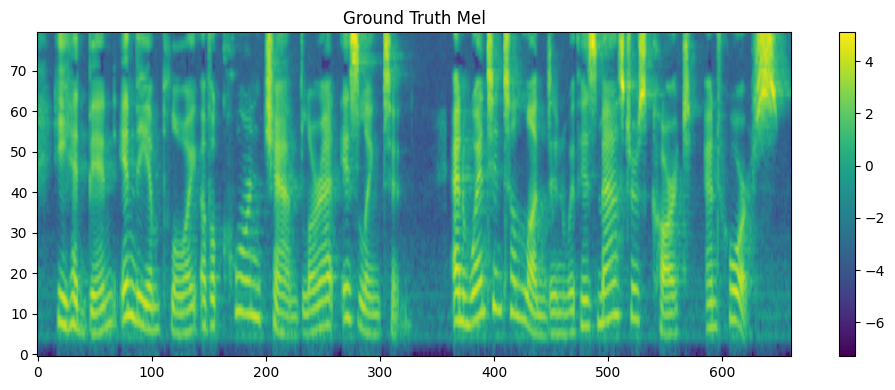

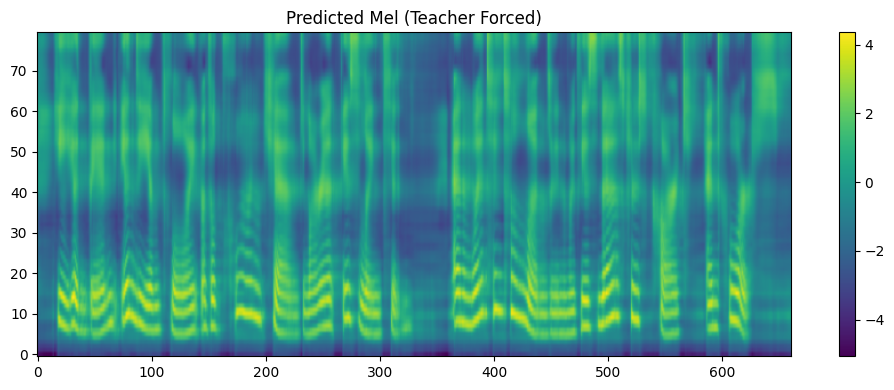

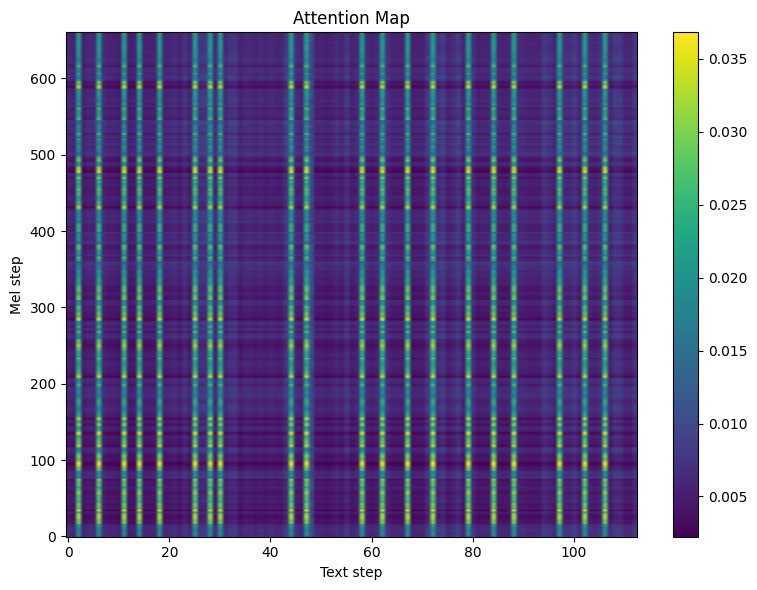

In [30]:
# =========================
# Cell 31: TEACHER-FORCED SAMPLE
# =========================
@torch.no_grad()
def inspect_validation_sample(model, dataset, index=0):
    model.eval()

    item = dataset[index]
    text_ids = item["text_ids"].unsqueeze(0).to(DEVICE)
    text_lens = torch.LongTensor([item["text_ids"].shape[0]]).to(DEVICE)
    target_mel = item["mel"].unsqueeze(0).to(DEVICE)

    mel_out, mel_post, stop_out, attn = model(
        text_ids=text_ids,
        text_lens=text_lens,
        target_mels=target_mel,
        teacher_forcing=True,
        max_steps=target_mel.size(2),
    )

    target = target_mel[0].detach().cpu().numpy()
    pred = mel_post[0].detach().cpu().numpy()
    attn_map = attn[0].detach().cpu().numpy()

    print("Text:", item["text"])
    plot_mel(target, "Ground Truth Mel")
    plot_mel(pred, "Predicted Mel (Teacher Forced)")
    plot_attention(attn_map, "Attention Map")

inspect_validation_sample(model, val_dataset, index=0)

In [31]:
# =========================
# Cell 32: INFERENCE MEL
# =========================
@torch.no_grad()
def infer_mel(model, text, max_steps=700):
    model.eval()

    ids = torch.LongTensor(text_to_ids(text)).unsqueeze(0).to(DEVICE)
    lens = torch.LongTensor([ids.shape[1]]).to(DEVICE)

    mel_out, mel_post, stop_out, attn = model(
        text_ids=ids,
        text_lens=lens,
        target_mels=None,
        teacher_forcing=False,
        max_steps=max_steps,
    )

    mel = mel_post[0].detach().cpu().numpy()
    attn_map = attn[0].detach().cpu().numpy()
    stop_sigmoid = torch.sigmoid(stop_out[0]).detach().cpu().numpy()

    return mel, attn_map, stop_sigmoid

Pred mel shape: (80, 500)


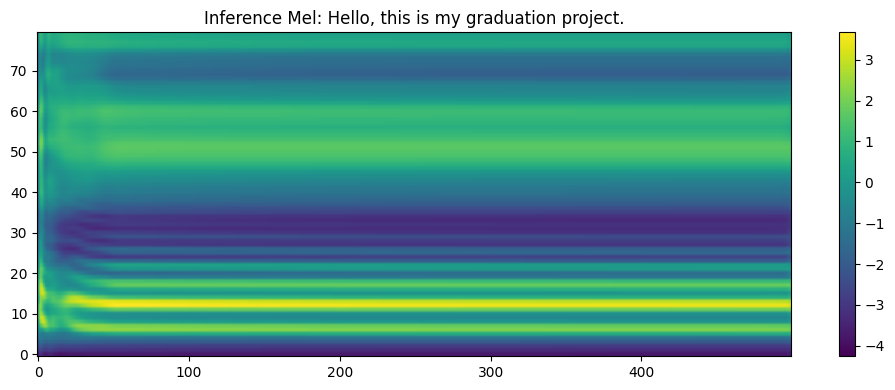

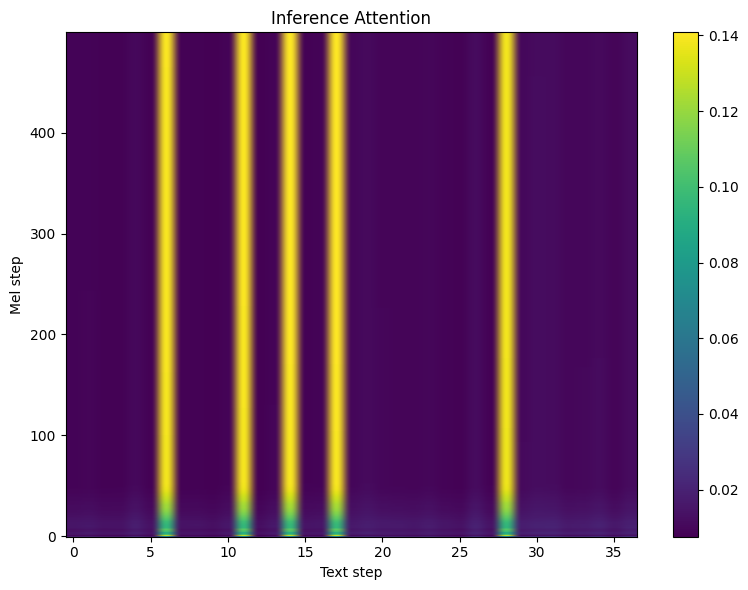

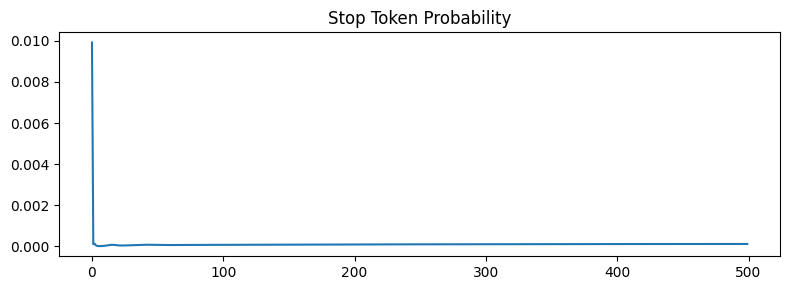

In [32]:
# =========================
# Cell 33: TEST INFERENCE
# =========================
test_text = "Hello, this is my graduation project."
pred_mel, attn_map, stop_sigmoid = infer_mel(model, test_text, max_steps=500)

print("Pred mel shape:", pred_mel.shape)
plot_mel(pred_mel, f"Inference Mel: {test_text}")
plot_attention(attn_map, "Inference Attention")

plt.figure(figsize=(8, 3))
plt.plot(stop_sigmoid)
plt.title("Stop Token Probability")
plt.tight_layout()
plt.show()

In [33]:
# =========================
# Cell 34: SAVE SAMPLE OUTPUTS
# =========================
np.save(CFG.sample_dir / "pred_mel.npy", pred_mel)
print("Saved:", CFG.sample_dir / "pred_mel.npy")

Saved: /kaggle/working/tts_transformer_taco_v2/samples/pred_mel.npy
